Accuracy: 1.0


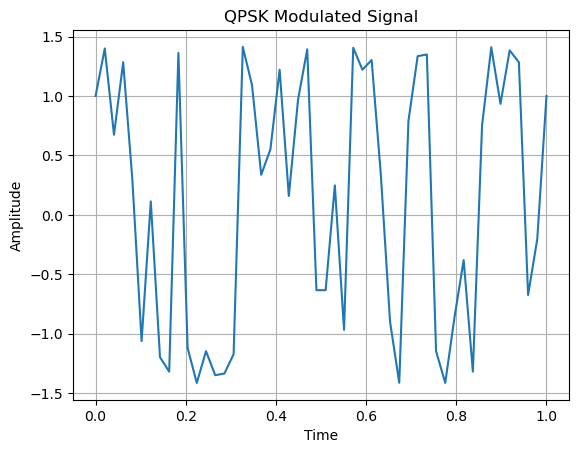

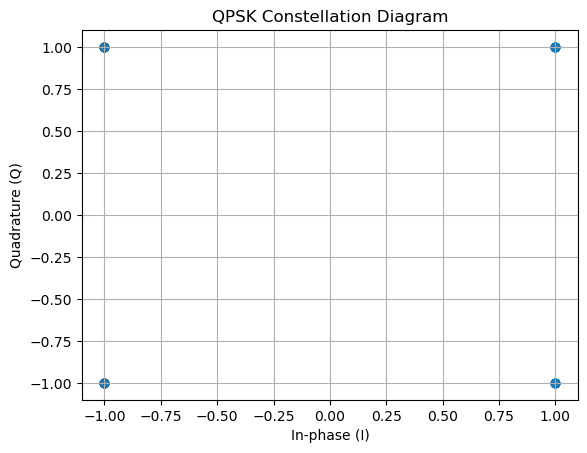

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random bits
num_bits = 100
bits = np.random.randint(0, 2, num_bits)

# Group bits into pairs
bit_pairs = bits.reshape((-1, 2))

# Mapping (Gray coding)
mapping = {
    (0, 0): (1, 1),
    (0, 1): (-1, 1),
    (1, 1): (-1, -1),
    (1, 0): (1, -1)
}

# Modulation
I = []
Q = []

for pair in bit_pairs:
    i, q = mapping[tuple(pair)]
    I.append(i)
    Q.append(q)

I = np.array(I)
Q = np.array(Q)

# Time axis
t = np.linspace(0, 1, len(I))

# Carrier signals
fc = 5
carrier_I = np.cos(2 * np.pi * fc * t)
carrier_Q = np.sin(2 * np.pi * fc * t)

# QPSK Signal
signal = I * carrier_I + Q * carrier_Q

# Plot modulated signal
plt.figure()
plt.plot(t, signal)
plt.title("QPSK Modulated Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# Constellation diagram
plt.figure()
plt.scatter(I, Q)
plt.title("QPSK Constellation Diagram")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid()

# Demodulation
received_bits = []

for i, q in zip(I, Q):
    if i > 0 and q > 0:
        received_bits.extend([0, 0])
    elif i < 0 and q > 0:
        received_bits.extend([0, 1])
    elif i < 0 and q < 0:
        received_bits.extend([1, 1])
    else:
        received_bits.extend([1, 0])

received_bits = np.array(received_bits)

# Accuracy
accuracy = np.sum(bits == received_bits) / len(bits)
print("Accuracy:", accuracy)

plt.show()

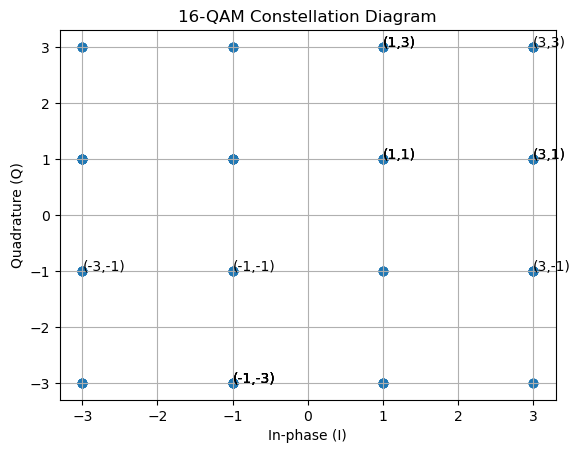

In [2]:
#lab-2
import numpy as np
import matplotlib.pyplot as plt

# Number of bits
num_bits = 400

# Generate random bits
bits = np.random.randint(0, 2, num_bits)

# Group bits into 4 (since 16-QAM)
bit_groups = bits.reshape((-1, 4))

# Mapping (Gray coding)
mapping_table = {
    (0,0,0,0): (-3, -3),
    (0,0,0,1): (-3, -1),
    (0,0,1,1): (-3, +1),
    (0,0,1,0): (-3, +3),
    
    (0,1,0,0): (-1, -3),
    (0,1,0,1): (-1, -1),
    (0,1,1,1): (-1, +1),
    (0,1,1,0): (-1, +3),
    
    (1,1,0,0): (+1, -3),
    (1,1,0,1): (+1, -1),
    (1,1,1,1): (+1, +1),
    (1,1,1,0): (+1, +3),
    
    (1,0,0,0): (+3, -3),
    (1,0,0,1): (+3, -1),
    (1,0,1,1): (+3, +1),
    (1,0,1,0): (+3, +3)
}

# Map bits to symbols
I = []
Q = []

for group in bit_groups:
    i, q = mapping_table[tuple(group)]
    I.append(i)
    Q.append(q)

I = np.array(I)
Q = np.array(Q)

# Constellation plot
plt.figure()
plt.scatter(I, Q)

# Labeling points (optional)
for i, q in zip(I[:16], Q[:16]):
    plt.text(i, q, f'({i},{q})')

plt.title("16-QAM Constellation Diagram")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid()

plt.show()

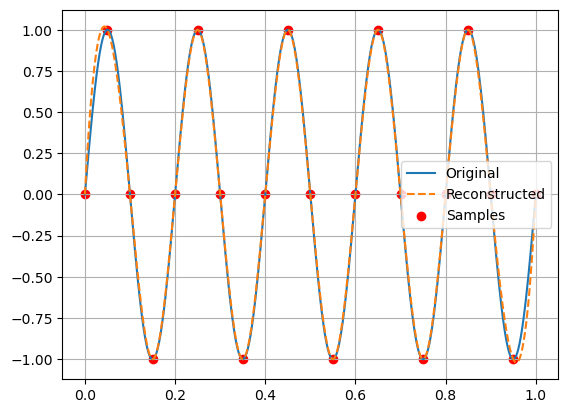

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Continuous signal
t = np.linspace(0, 1, 1000)
f = 5
x = np.sin(2 * np.pi * f * t)

# Sampling
fs = 20
ts = np.arange(0, 1 + 1/fs, 1/fs)
xs = np.sin(2 * np.pi * f * ts)

# Reconstruction (FIXED)
interp_func = interp1d(ts, xs, kind='cubic', fill_value="extrapolate")
xr = interp_func(t)

# Plot
plt.plot(t, x, label="Original")
plt.plot(t, xr, '--', label="Reconstructed")
plt.scatter(ts, xs, color='red', label="Samples")
plt.legend()
plt.grid()
plt.show()

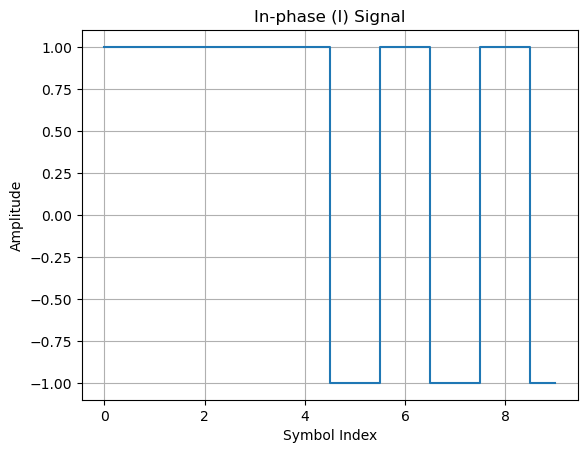

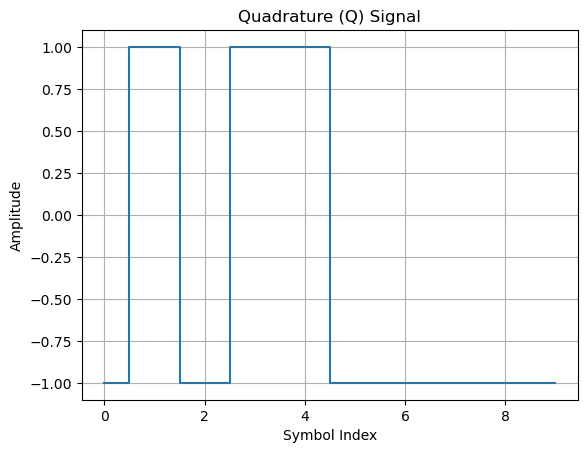

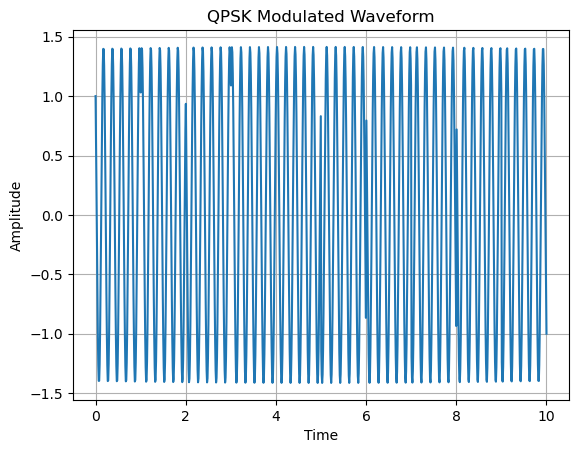

In [5]:
#lab-4
import numpy as np
import matplotlib.pyplot as plt

# Generate random bits
num_bits = 20
bits = np.random.randint(0, 2, num_bits)

# Ensure even number of bits
if len(bits) % 2 != 0:
    bits = np.append(bits, 0)

# Group bits into pairs
bit_pairs = bits.reshape((-1, 2))

# Mapping (Gray coding)
mapping = {
    (0, 0): (1, 1),
    (0, 1): (-1, 1),
    (1, 1): (-1, -1),
    (1, 0): (1, -1)
}

I = []
Q = []

for pair in bit_pairs:
    i, q = mapping[tuple(pair)]
    I.append(i)
    Q.append(q)

I = np.array(I)
Q = np.array(Q)

# Time parameters
Tb = 1        # bit duration
fc = 5        # carrier frequency
t = np.linspace(0, Tb * len(I), 1000)

# Expand I and Q to match time axis
I_signal = np.repeat(I, len(t)//len(I))
Q_signal = np.repeat(Q, len(t)//len(Q))

# Carrier signals
carrier_I = np.cos(2 * np.pi * fc * t)
carrier_Q = np.sin(2 * np.pi * fc * t)

# QPSK Signal
qpsk_signal = I_signal * carrier_I + Q_signal * carrier_Q

# Plot I signal
plt.figure()
plt.step(range(len(I)), I, where='mid')
plt.title("In-phase (I) Signal")
plt.xlabel("Symbol Index")
plt.ylabel("Amplitude")
plt.grid()

# Plot Q signal
plt.figure()
plt.step(range(len(Q)), Q, where='mid')
plt.title("Quadrature (Q) Signal")
plt.xlabel("Symbol Index")
plt.ylabel("Amplitude")
plt.grid()

# Plot QPSK waveform
plt.figure()
plt.plot(t, qpsk_signal)
plt.title("QPSK Modulated Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

plt.show()

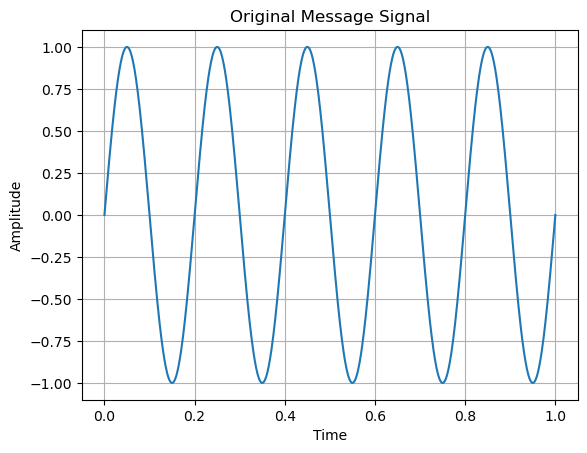

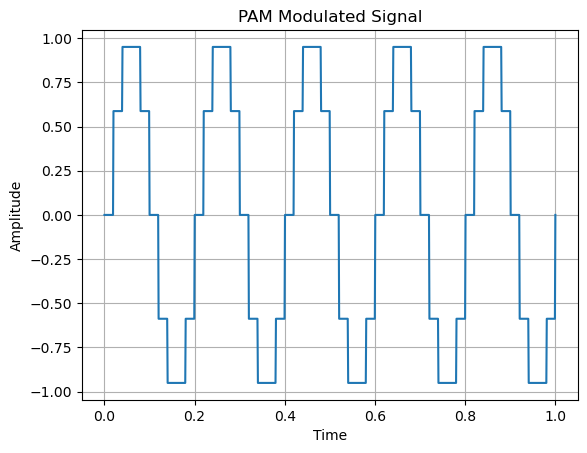

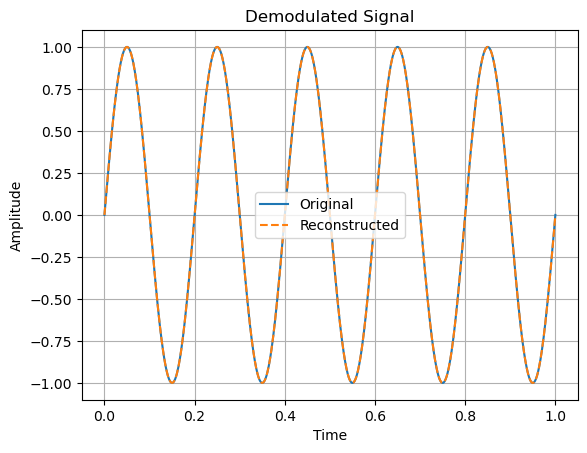

In [6]:
#lab-05
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Time axis for continuous signal
t = np.linspace(0, 1, 1000)

# Message signal (sine wave)
fm = 5
message = np.sin(2 * np.pi * fm * t)

# Sampling parameters
fs = 50
ts = np.arange(0, 1 + 1/fs, 1/fs)
samples = np.sin(2 * np.pi * fm * ts)

# Generate PAM signal (flat-top)
pam_signal = np.zeros_like(t)

for i in range(len(ts)):
    idx = np.where((t >= ts[i]) & (t < ts[i] + 1/fs))
    pam_signal[idx] = samples[i]

# Demodulation (reconstruction using interpolation)
interp_func = interp1d(ts, samples, kind='cubic', fill_value="extrapolate")
reconstructed = interp_func(t)

# Plot message signal
plt.figure()
plt.plot(t, message)
plt.title("Original Message Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# Plot PAM signal
plt.figure()
plt.plot(t, pam_signal)
plt.title("PAM Modulated Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# Plot reconstructed signal
plt.figure()
plt.plot(t, message, label="Original")
plt.plot(t, reconstructed, '--', label="Reconstructed")
plt.title("Demodulated Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.show()

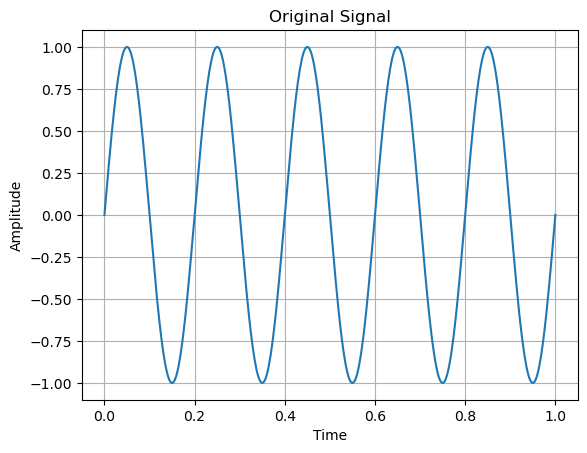

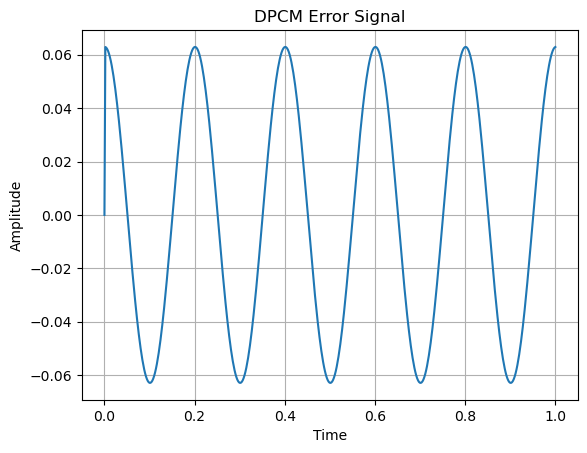

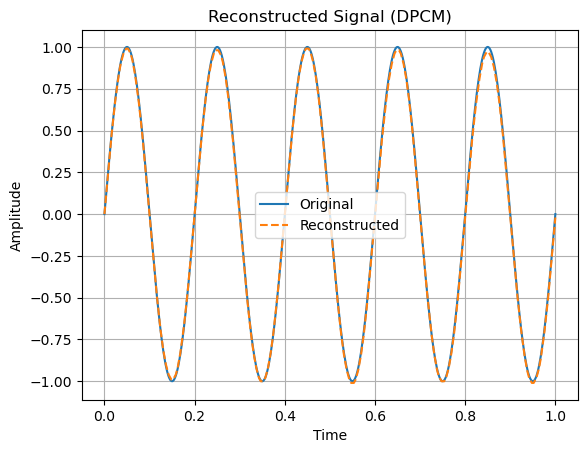

In [7]:
#lab-06
import numpy as np
import matplotlib.pyplot as plt

# Generate input signal
t = np.linspace(0, 1, 500)
x = np.sin(2 * np.pi * 5 * t)

# DPCM Encoding
predicted = np.zeros_like(x)
error = np.zeros_like(x)

for i in range(1, len(x)):
    predicted[i] = x[i-1]          # simple predictor
    error[i] = x[i] - predicted[i]

# Quantization (simple rounding)
quantized_error = np.round(error, 2)

# DPCM Decoding
reconstructed = np.zeros_like(x)

for i in range(1, len(x)):
    reconstructed[i] = reconstructed[i-1] + quantized_error[i]

# Plot original signal
plt.figure()
plt.plot(t, x)
plt.title("Original Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# Plot error signal
plt.figure()
plt.plot(t, error)
plt.title("DPCM Error Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# Plot reconstructed signal
plt.figure()
plt.plot(t, x, label="Original")
plt.plot(t, reconstructed, '--', label="Reconstructed")
plt.title("Reconstructed Signal (DPCM)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.show()